In [1]:
import os

import torch
import torch.optim as optim
from torch.nn import CrossEntropyLoss
from torch.nn import functional as F
from torch.optim import Adam, AdamW

os.environ["WANDB_API_KEY"] = "KEY"
os.environ["WANDB_MODE"] = 'offline'
from itertools import combinations

import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset
import random
import csv
from torch import Tensor
import itertools
import math
import re
import numpy as np
import argparse
import pickle


from PIL import Image
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from sklearn.model_selection import train_test_split
import pandas as pd
from torch.utils.data import random_split

In [2]:
class ModelConfig:
    def __init__(self,
                 input_neuron=88,        # 默认88个神经元（test_firing_rate_matrix）
                 time_bins=12,           # 默认12个时间bin（analysis_neuron_30k中300ms/25ms）
                 d_model=150,
                 nhead=10,
                 num_transformer_layers=1,
                 conv_channels=64,
                 num_conv_blocks=3,
                 num_classes=100,        # 100张图像分类
                 residual_dims=[256, 512, 1024],
                 use_positional_encoding=True,
                 dim_feedforward_ratio=4,
                 activation='relu'):
        # Transformer
        self.transformer = {
            'd_model': d_model,
            'nhead': nhead,
            'num_layers': num_transformer_layers,
            'dim_feedforward': d_model * dim_feedforward_ratio,
            'activation': activation
        }

        # cnn
        self.convolution = {
            'channels': conv_channels,
            'num_blocks': num_conv_blocks,
            'kernel_size': (3, 3),
            'pool_size': (2, 2)
        }

        # resnet
        self.residual = {
            'dims': residual_dims,
            'skip_connection': True
        }

        self.input_dim = input_neuron
        self.time_steps = time_bins
        self.num_classes = num_classes
        self.positional_encoding = use_positional_encoding
        self.lr = 2e-4
        self.epochs = 80

In [3]:

class ResidualLinearBlock(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.activation = nn.GELU()
        self.downsample = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()

    def forward(self, x):
        residual = self.downsample(x)
        x = self.linear(x)
        x = self.norm(x)
        x = self.activation(x)
        return x + residual

class TimeTransformerConvModel(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config
        
        self.input_proj = nn.Linear(config.input_dim, config.transformer['d_model'])
        self.pos_encoder = PositionalEncoding(config.transformer['d_model']) if config.positional_encoding else nn.Identity()
        
        transformer_layer = nn.TransformerEncoderLayer(
            d_model=config.transformer['d_model'],
            nhead=config.transformer['nhead'],
            dim_feedforward=config.transformer['dim_feedforward'],
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(transformer_layer, config.transformer['num_layers'])
        
        self.conv_blocks = nn.Sequential()
        in_channels = 1
        for _ in range(config.convolution['num_blocks']):
            self.conv_blocks.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, config.convolution['channels'], 
                            kernel_size=config.convolution['kernel_size'], padding='same'),
                    nn.BatchNorm2d(config.convolution['channels']),
                    nn.ELU(),
                    nn.MaxPool2d(kernel_size=config.convolution['pool_size'])
                )
            )
            in_channels = config.convolution['channels']
        
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(config.convolution['channels'], config.num_classes)
        
        # 修复残差层的维度问题
        self.residual_layers = nn.Sequential()
        current_dim = config.convolution['channels']
        for dim in config.residual['dims']:
            self.residual_layers.append(ResidualLinearBlock(current_dim, dim))
            current_dim = dim
        # 确保最终输出维度是512（与CLIP特征维度匹配）
        if current_dim != 512:
            self.residual_layers.append(nn.Linear(current_dim, 512))
            self.residual_layers.append(nn.LayerNorm(512))


    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        
        x = x.unsqueeze(1)
        x = self.conv_blocks(x)
        x = self.adaptive_pool(x)
        x = x.flatten(1)
        
        logits = self.classifier(x)
        features = self.residual_layers(x)
        
        return logits, features

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1)]
        return x

In [4]:
class MultitaskLoss(nn.Module):
    def __init__(self, alpha=0, temp=0.07):
        super().__init__()
        self.alpha = alpha      # 分类损失权重
        self.temp = temp
        self.ce_loss = nn.CrossEntropyLoss()
    
    def contrastive_loss(self, h_neuro, h_img):
        h_neuro = F.normalize(h_neuro, dim=1) + 1e-10
        h_img = F.normalize(h_img, dim=1) + 1e-10
        
        logits_ab = torch.matmul(h_neuro, h_img.T) / self.temp
        logits_ba = torch.matmul(h_img, h_neuro.T) / self.temp
        
        labels = torch.arange(h_neuro.size(0), device=h_neuro.device)
        loss_ab = F.cross_entropy(logits_ab, labels)
        loss_ba = F.cross_entropy(logits_ba, labels)
        
        return (loss_ab + loss_ba) / 2
    
    def forward(self, logits, labels, img_feature, features):
        loss_cls = self.ce_loss(logits, labels)
        loss_cont = self.contrastive_loss(features, img_feature)
        total_loss = self.alpha * loss_cls + (1 - self.alpha) * loss_cont
        return total_loss

In [5]:
def train_model(model, dataloader, optimizer, device, criterion, config):
    model.train()
    total_loss = 0.0
    
    for batch_idx, (neuro, labels, img_feature) in enumerate(dataloader):
        neuro = neuro.to(device)
        labels = labels.to(device)
        img_feature = img_feature.to(device)

        optimizer.zero_grad()
        
        logits, features = model(neuro)
        loss = criterion(logits, labels, img_feature, features)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            parameters=model.parameters(), 
            max_norm=3.0,                   
            norm_type=2.0                   
        )
        optimizer.step()
        
        total_loss += loss.item()
        
    train_loss = total_loss / len(dataloader)
    return train_loss

@torch.no_grad()
def evaluate_model(model, dataloader, device, criterion, config):
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_labels = []
    
    for neuro, labels, img_feature in dataloader:
        neuro = neuro.to(device)
        labels = labels.to(device)
        img_feature = img_feature.to(device)
        
        logits, features = model(neuro)
        loss = criterion(logits, labels, img_feature, features)
        total_loss += loss.item()
        
        # 收集预测结果和真实标签
        predictions = torch.argmax(logits, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    # 转换为numpy数组
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # 计算分类指标
    # Top-1 Accuracy (准确率)
    top1_acc = (all_predictions == all_labels).mean()
    
    # Top-5 Accuracy (需要计算概率排序)
    # 由于我们只有logits，需要重新计算top-5准确率
    model.eval()
    top5_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for neuro, labels, img_feature in dataloader:
            neuro = neuro.to(device)
            labels = labels.to(device)
            
            logits, features = model(neuro)
            # 获取top-5预测
            _, top5_preds = torch.topk(logits, 5, dim=1)
            
            # 检查真实标签是否在top-5中
            for i, true_label in enumerate(labels):
                if true_label in top5_preds[i]:
                    top5_correct += 1
                total_samples += 1
    
    top5_acc = top5_correct / total_samples if total_samples > 0 else 0.0
    
    val_loss = total_loss / len(dataloader)
    
    return {
        "val_loss": val_loss,
        "top1_acc": top1_acc,
        "top5_acc": top5_acc
    }

In [6]:
def main_train_loop(config, model, train_loader, test_loader, device, image_cluster=None):
    optimizer = AdamW(model.parameters(), lr=config.lr)
    # 修复：设置alpha=0.5，平衡分类损失和对比学习损失
    criterion = MultitaskLoss(alpha=1, temp=0.07)
    
    train_losses = []
    val_losses = []
    top1_accs = []
    top5_accs = []
    best_top1_acc = 0.0
    
    for epoch in range(config.epochs):
        train_loss = train_model(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device,
            criterion=criterion,
            config=config
        )
        
        metrics = evaluate_model(
            model=model,
            dataloader=test_loader,
            device=device,
            criterion=criterion,
            config=config
        )
        
        train_losses.append(train_loss)
        val_losses.append(metrics["val_loss"])
        top1_accs.append(metrics["top1_acc"])
        top5_accs.append(metrics["top5_acc"])
        
        if metrics["top1_acc"] > best_top1_acc:
            best_top1_acc = metrics["top1_acc"]
            torch.save(model, "best_model_VISp.pth")
            best_epoch = epoch
        
        print(f"Epoch {epoch+1}/{config.epochs}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {metrics['val_loss']:.4f}")
        print(f"Top-1 Acc: {metrics['top1_acc']:.4f} | Top-5 Acc: {metrics['top5_acc']:.4f}")
        print("-" * 60)
        
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(top1_accs, label="Top-1 Accuracy")
    plt.plot(top5_accs, label="Top-5 Accuracy")
    plt.title("Classification Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.tight_layout()
    plt.close()
    
    return {
        "best_top1_acc": best_top1_acc,
        "train_history": {
            "loss": train_losses
        },
        "val_history": {
            "loss": val_losses,
            "top1_acc": top1_accs,
            "top5_acc": top5_accs
        },
        "best_epoch": best_epoch
    }

In [7]:
# 加载 analysis_neuron_30k.ipynb 生成的 test_firing_rate_matrix 和元数据
# 数据形状: (total_trials, n_neuron, time_bin) = (2776, 88, 12)，对应100张图像的所有trial展平
matrix_path = "/media/ubuntu/sda/duan/result/251205_30k/test_firing_rate_matrix_oracle.npy"
meta_path = "/media/ubuntu/sda/duan/result/251205_30k/test_metadata.csv"

if not os.path.exists(matrix_path):
    raise FileNotFoundError(f"找不到 test_firing_rate_matrix: {matrix_path}")
if not os.path.exists(meta_path):
    raise FileNotFoundError(f"找不到元数据: {meta_path}")

test_firing_rate_matrix = np.load(matrix_path)  # (total_trials, n_neuron, time_bin)
test_meta = pd.read_csv(meta_path)              # 包含 image_id, trial_index, n_trials 等

total_trials, n_neurons, time_bins = test_firing_rate_matrix.shape
print(f"test_firing_rate_matrix 形状: {test_firing_rate_matrix.shape}")
print(f"test_meta 行数: {len(test_meta)} | 列: {test_meta.columns.tolist()}")

assert len(test_meta) == total_trials, "元数据行数需与trial数一致"
assert 'image_id' in test_meta.columns, "元数据必须包含 image_id 列"

# 100张图像（image_id唯一值）
image_ids = sorted(test_meta['image_id'].unique())
print(f"唯一图像数: {len(image_ids)}")

test_firing_rate_matrix 形状: (1538, 16, 30)
test_meta 行数: 1538 | 列: ['image_id', 'image_path', 'rec_codes_points', 'trial_index', 'n_trials']
唯一图像数: 100


In [9]:
class FiringRateDataset(Dataset):
    def __init__(self, fr_matrix: np.ndarray, meta: pd.DataFrame):
        """
        fr_matrix: (total_trials, n_neuron, time_bin) - 所有trial展平后的格式
        meta: DataFrame，index按trial顺序，需包含 image_id 列
        """
        assert fr_matrix.ndim == 3, "fr_matrix 需为3维"
        assert 'image_id' in meta.columns, "meta 需包含 image_id 列"
        assert fr_matrix.shape[0] == len(meta), "trial数需与元数据行数一致"

        self.fr_matrix = fr_matrix
        self.meta = meta.reset_index(drop=True)
        self.total_trials = fr_matrix.shape[0]
        self.n_neurons = fr_matrix.shape[1]
        self.time_bins = fr_matrix.shape[2]

        # 将 image_id 映射为 [0, num_classes)
        unique_ids = sorted(self.meta['image_id'].unique())
        self.id2cls = {img_id: idx for idx, img_id in enumerate(unique_ids)}
        self.num_classes = len(unique_ids)

    def __len__(self):
        return self.total_trials

    def __getitem__(self, idx):
        # 取出单个 trial: (n_neuron, time_bin) -> (time_bin, n_neuron)
        trial_matrix = self.fr_matrix[idx, :, :].T  # (time_bin, n_neuron)
        data_tensor = torch.tensor(trial_matrix, dtype=torch.float32)

        image_id = str(self.meta.loc[idx, 'image_id'])  # 使用str因为image_id可能是字符串
        label = torch.tensor(self.id2cls[image_id], dtype=torch.long)

        # 沿用原训练流程的占位图像特征
        dummy_feature = torch.zeros(512, dtype=torch.float32)
        return data_tensor, label, dummy_feature

In [10]:
def train_firing_rate_classification(fr_matrix, meta, device):
    """
    使用 test_firing_rate_matrix 进行 100 类图像分类训练
    """
    dataset = FiringRateDataset(fr_matrix, meta)
    num_classes = dataset.num_classes
    print(f"数据集大小: {len(dataset)} | 类别数: {num_classes}")

    # 划分训练/验证集
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    config = ModelConfig(
        input_neuron=dataset.n_neurons,
        time_bins=dataset.time_bins,
        num_classes=num_classes
    )
    model = TimeTransformerConvModel(config).to(device)

    # 这里只有分类监督，alpha=1避免无意义的对比损失
    optimizer = AdamW(model.parameters(), lr=config.lr)
    criterion = MultitaskLoss(alpha=1.0, temp=0.07)

    train_losses, val_losses = [], []
    top1_accs, top5_accs = [], []
    best_top1_acc = 0.0

    for epoch in range(config.epochs):
        train_loss = train_model(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device,
            criterion=criterion,
            config=config
        )

        metrics = evaluate_model(
            model=model,
            dataloader=val_loader,
            device=device,
            criterion=criterion,
            config=config
        )

        train_losses.append(train_loss)
        val_losses.append(metrics["val_loss"])
        top1_accs.append(metrics["top1_acc"])
        top5_accs.append(metrics["top5_acc"])

        if metrics["top1_acc"] > best_top1_acc:
            best_top1_acc = metrics["top1_acc"]
            best_epoch = epoch
            torch.save(model, "best_model_100img.pth")

        print(f"Epoch {epoch+1}/{config.epochs}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {metrics['val_loss']:.4f}")
        print(f"Top-1 Acc: {metrics['top1_acc']:.4f} | Top-5 Acc: {metrics['top5_acc']:.4f}")
        print("-" * 60)

    return {
        "best_top1_acc": best_top1_acc,
        "train_history": {"loss": train_losses},
        "val_history": {
            "loss": val_losses,
            "top1_acc": top1_accs,
            "top5_acc": top5_accs
        },
        "best_epoch": best_epoch
    }, model

# 启动训练
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

results, model = train_firing_rate_classification(
    fr_matrix=test_firing_rate_matrix,
    meta=test_meta,
    device=device
)


使用设备: cuda
数据集大小: 1538 | 类别数: 100
Epoch 1/80
Train Loss: 4.6927 | Val Loss: 4.6492
Top-1 Acc: 0.0097 | Top-5 Acc: 0.0422
------------------------------------------------------------
Epoch 2/80
Train Loss: 4.6169 | Val Loss: 4.6591
Top-1 Acc: 0.0097 | Top-5 Acc: 0.0487
------------------------------------------------------------
Epoch 3/80
Train Loss: 4.5957 | Val Loss: 4.6524
Top-1 Acc: 0.0032 | Top-5 Acc: 0.0519
------------------------------------------------------------
Epoch 4/80
Train Loss: 4.5783 | Val Loss: 4.6574
Top-1 Acc: 0.0097 | Top-5 Acc: 0.0519
------------------------------------------------------------
Epoch 5/80
Train Loss: 4.5660 | Val Loss: 4.6649
Top-1 Acc: 0.0097 | Top-5 Acc: 0.0390
------------------------------------------------------------
Epoch 6/80
Train Loss: 4.5448 | Val Loss: 4.6648
Top-1 Acc: 0.0065 | Top-5 Acc: 0.0519
------------------------------------------------------------
Epoch 7/80
Train Loss: 4.5305 | Val Loss: 4.6816
Top-1 Acc: 0.0065 | Top-5 Acc

KeyboardInterrupt: 

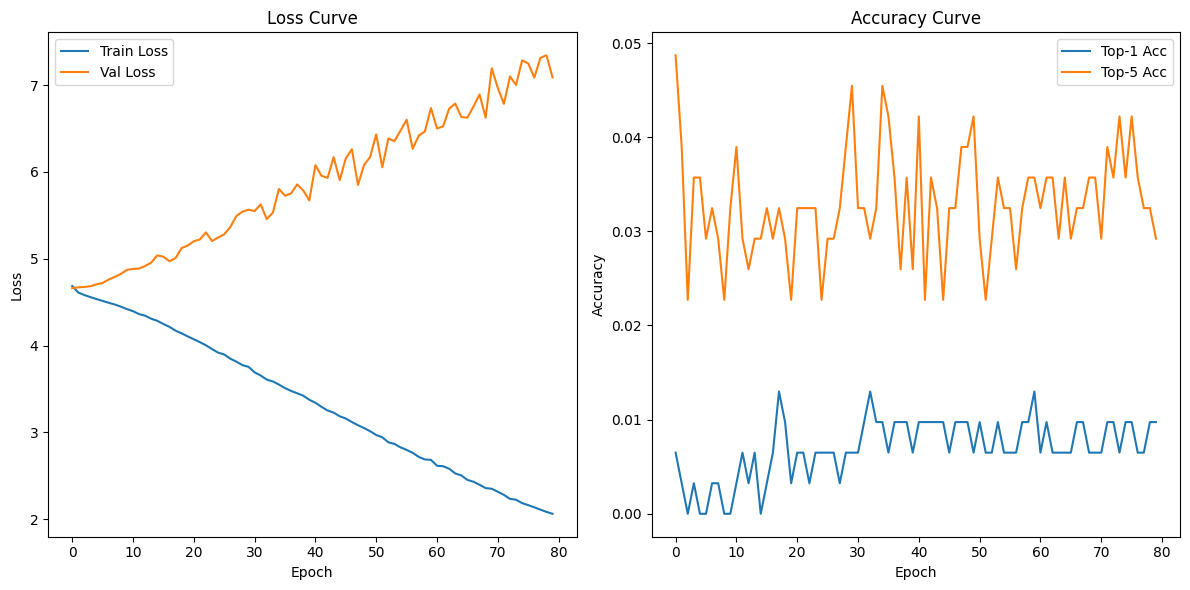


=== 训练结果总结 ===
最佳 Top-1 Acc: 0.0130
最佳 Top-5 Acc: 0.0487
最佳 Epoch: 17


In [ ]:
# 训练过程可视化（单任务：100类图像分类）
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(results['train_history']['loss'], label='Train Loss')
plt.plot(results['val_history']['loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results['val_history']['top1_acc'], label='Top-1 Acc')
plt.plot(results['val_history']['top5_acc'], label='Top-5 Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== 训练结果总结 ===")
print(f"最佳 Top-1 Acc: {results['best_top1_acc']:.4f}")
print(f"最佳 Top-5 Acc: {max(results['val_history']['top5_acc']):.4f}")
print(f"最佳 Epoch: {results['best_epoch']}")
